In [2]:
import pandas as pd
import numpy as np
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [4]:
df = pd.read_csv("customer_support_tickets.csv")

df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [5]:
print(df.shape)

print(df.columns)

(8469, 17)
Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')


In [6]:
df = df[
    [
        'Ticket Description',
        'Ticket Type',
        'Ticket Priority'
    ]
]

df.head()

,Ticket Description,Ticket Type,Ticket Priority
0,I'm having an issue with the {product_purchase...,Technical issue,Critical
1,I'm having an issue with the {product_purchase...,Technical issue,Critical
2,I'm facing a problem with my {product_purchase...,Technical issue,Low
3,I'm having an issue with the {product_purchase...,Billing inquiry,Low
4,I'm having an issue with the {product_purchase...,Billing inquiry,Low


In [9]:
print(df.isnull().sum())

Ticket Description    0
Ticket Type           0
Ticket Priority       0
dtype: int64


In [10]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(
        r'[^a-zA-Z\s]',
        '',
        text
    )

    words = word_tokenize(text)

    stop_words = set(
        stopwords.words('english')
    )

    words = [
        word
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [13]:
df['Cleaned_Text'] = df[
    'Ticket Description'
].apply(clean_text)

df.head()

,Ticket Description,Ticket Type,Ticket Priority,Cleaned_Text
0,I'm having an issue with the {product_purchase...,Technical issue,Critical,im issue productpurchased please assist billin...
1,I'm having an issue with the {product_purchase...,Technical issue,Critical,im issue productpurchased please assist need c...
2,I'm facing a problem with my {product_purchase...,Technical issue,Low,im facing problem productpurchased productpurc...
3,I'm having an issue with the {product_purchase...,Billing inquiry,Low,im issue productpurchased please assist proble...
4,I'm having an issue with the {product_purchase...,Billing inquiry,Low,im issue productpurchased please assist note s...


In [14]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(
    df['Cleaned_Text']
)

In [15]:
y = df['Ticket Type']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
model = MultinomialNB()

model.fit(
    X_train,
    y_train
)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [18]:
y_pred = model.predict(
    X_test
)

In [19]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    accuracy
)

Accuracy: 0.18772136953955135


In [20]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

                      precision    recall  f1-score   support

     Billing inquiry       0.15      0.04      0.07       357
Cancellation request       0.18      0.15      0.17       327
     Product inquiry       0.14      0.11      0.12       316
      Refund request       0.19      0.30      0.24       345
     Technical issue       0.21      0.32      0.26       349

            accuracy                           0.19      1694
           macro avg       0.18      0.19      0.17      1694
        weighted avg       0.18      0.19      0.17      1694



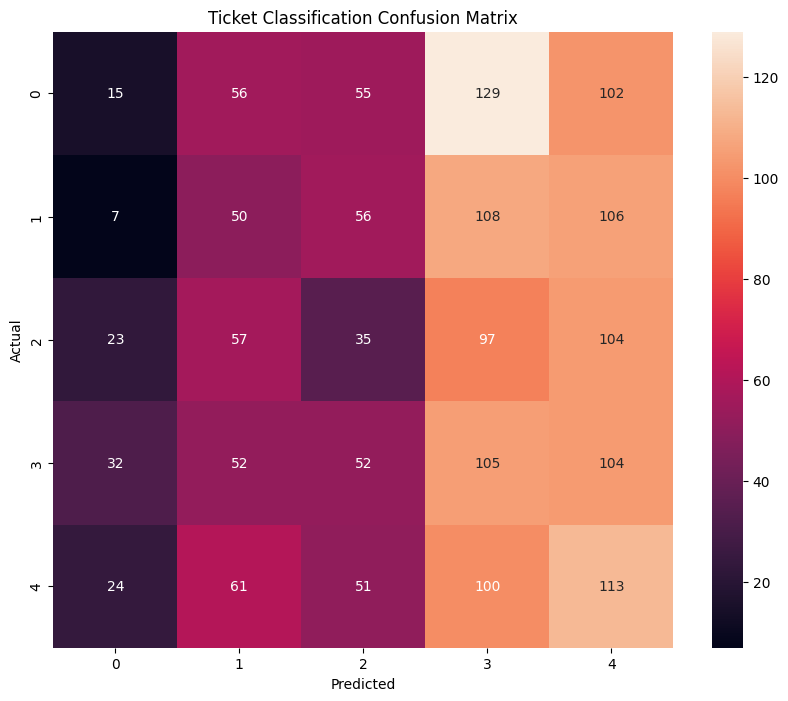

In [21]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Ticket Classification Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

In [22]:
df['Ticket Priority'].value_counts()

Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

In [23]:
new_ticket = [
    "Unable to login to my account after password reset"
]

new_ticket_clean = [
    clean_text(text)
    for text in new_ticket
]

new_ticket_vector = vectorizer.transform(
    new_ticket_clean
)

prediction = model.predict(
    new_ticket_vector
)

print(
    "Predicted Ticket Type:",
    prediction[0]
)

Predicted Ticket Type: Cancellation request


Conclusion

This project successfully classifies customer support tickets using Natural Language Processing and Machine Learning. Ticket descriptions were cleaned and converted into numerical features using TF-IDF. A Multinomial Naive Bayes classifier was trained to predict ticket categories. The model was evaluated using accuracy, classification report, and confusion matrix analysis.